## Installing and Importing Required Libraries

In [1]:
!pip install -q python-dotenv
!pip install -q anthropic
!pip install -q JPype1
!pip install -q jaydebeapi


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import os
import re
import glob
import json
import base64
import urllib.parse

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jpype
import jaydebeapi
import anthropic

from dotenv import load_dotenv
load_dotenv()

%matplotlib inline

## Importing and Preparing the EV Charging Dataset

In [3]:
DATA_URL = (
    "https://raw.githubusercontent.com/yvenn-amara/ev-load-open-data/master/"
    "1.%20Input%20Data/4.%20City%20of%20Palo%20Alto/ChargePoint%20Data%20CY20Q4.csv"
)

raw = pd.read_csv(DATA_URL, low_memory=False)
print("Raw shape:", raw.shape)

Raw shape: (259415, 33)


In [4]:
# Keep and rename the columns we will analyze to GridDB-safe names (no spaces or symbols).
keep = {
    "Station Name": "station_name",
    "Start Date": "_start",
    "End Date": "_end",
    "Energy (kWh)": "energy_kwh",
    "GHG Savings (kg)": "ghg_savings_kg",
    "Port Type": "port_type",
    "Plug Type": "plug_type",
    "Fee": "fee",
    "Ended By": "ended_by",
    "Latitude": "latitude",
    "Longitude": "longitude",
    "User ID": "user_id",
}
df = raw[list(keep)].rename(columns=keep).copy()

# Parse the start and end timestamps and drop rows we cannot use.
df["_start"] = pd.to_datetime(df["_start"], format="%m/%d/%Y %H:%M", errors="coerce")
df["_end"] = pd.to_datetime(df["_end"], format="%m/%d/%Y %H:%M", errors="coerce")
df = df.dropna(subset=["_start", "_end"])
df = df[df["_end"] >= df["_start"]]

# Fill a few light gaps in the text columns.
df["port_type"] = df["port_type"].fillna("Unknown")
df["ended_by"] = df["ended_by"].fillna("Unknown")
df["user_id"] = df["user_id"].fillna("Unknown").astype(str)

# The full dataset has more than 250,000 sessions. We take a seeded sample of 50,000
# that keeps the full 2011 to 2020 span so the load and the queries stay quick.
dataset = df.sample(n=50000, random_state=42).sort_values("_start").reset_index(drop=True)

# GridDB stores a TIMESTAMP as an ISO 8601 string ending in Z, so we format both columns.
dataset["start_ts"] = dataset["_start"].dt.strftime("%Y-%m-%dT%H:%M:%S.000Z")
dataset["end_ts"] = dataset["_end"].dt.strftime("%Y-%m-%dT%H:%M:%S.000Z")

# A LONG session_id is the row key. It has to be the first column.
dataset.insert(0, "session_id", np.arange(len(dataset), dtype="int64"))

for col in ["energy_kwh", "ghg_savings_kg", "fee", "latitude", "longitude"]:
    dataset[col] = dataset[col].astype("float64").round(6)

dataset = dataset[[
    "session_id", "station_name", "start_ts", "end_ts", "energy_kwh",
    "ghg_savings_kg", "port_type", "plug_type", "fee", "ended_by",
    "latitude", "longitude", "user_id",
]]

dataset.to_csv("ev_charging_palo_alto.csv", index=False)
print("Prepared shape:", dataset.shape)
dataset.head()

Prepared shape: (50000, 13)


,session_id,station_name,start_ts,end_ts,energy_kwh,ghg_savings_kg,port_type,plug_type,fee,ended_by,latitude,longitude,user_id
0,0,PALO ALTO CA / HAMILTON #1,2011-07-31T04:33:00.000Z,2011-07-31T10:40:00.000Z,17.171463,7.212,Level 2,J1772,0.0,Customer,37.444572,-122.160309,4447
1,1,PALO ALTO CA / HAMILTON #1,2011-08-02T14:00:00.000Z,2011-08-02T15:13:00.000Z,4.197217,1.763,Level 2,J1772,0.0,Plug Out at Vehicle,37.444572,-122.160309,2944
2,2,PALO ALTO CA / HAMILTON #2,2011-08-02T19:03:00.000Z,2011-08-02T21:30:00.000Z,8.497075,3.569,Level 2,J1772,0.0,Customer,37.444607,-122.160263,4169
3,3,PALO ALTO CA / HAMILTON #1,2011-08-05T05:45:00.000Z,2011-08-05T09:16:00.000Z,12.238361,5.140,Level 2,J1772,0.0,Customer,37.444572,-122.160309,4447
4,4,PALO ALTO CA / HAMILTON #2,2011-08-05T19:12:00.000Z,2011-08-05T20:26:00.000Z,3.956375,1.662,Level 2,J1772,0.0,Customer,37.444607,-122.160263,2545


## Storing the Sessions in GridDB (Web API)

### Creating a GridDB Connection

In [5]:
username = os.environ.get("azure_username")
password = os.environ.get("azure_password")
base_url = os.environ.get("azure_base_url")

url = f"{base_url}/checkConnection"

credentials = f"{username}:{password}"
encoded_credentials = base64.b64encode(credentials.encode()).decode()

headers = {
    'Content-Type': 'application/json',
    'Authorization': f'Basic {encoded_credentials}',
    'User-Agent': 'PostmanRuntime/7.29.0'
}

response = requests.get(url, headers=headers)

print(response.status_code)

200


### Creating a Container with a TIMESTAMP Column

In [6]:
# Mapping pandas dtypes to GridDB types
type_mapping = {
    "int64":      "LONG",
    "float64":    "DOUBLE",
    "bool":       "BOOL",
    "datetime64": "TIMESTAMP",
    "object":     "STRING",
    "category":   "STRING",
}

# start_ts and end_ts hold ISO 8601 strings, so we map them to TIMESTAMP by hand.
timestamp_cols = {"start_ts", "end_ts"}

columns = []
for col, dtype in dataset.dtypes.items():
    if col in timestamp_cols:
        griddb_type = "TIMESTAMP"
    else:
        griddb_type = type_mapping.get(str(dtype), "STRING")
    columns.append({"name": col, "type": griddb_type})

print(columns)

[{'name': 'session_id', 'type': 'LONG'}, {'name': 'station_name', 'type': 'STRING'}, {'name': 'start_ts', 'type': 'TIMESTAMP'}, {'name': 'end_ts', 'type': 'TIMESTAMP'}, {'name': 'energy_kwh', 'type': 'DOUBLE'}, {'name': 'ghg_savings_kg', 'type': 'DOUBLE'}, {'name': 'port_type', 'type': 'STRING'}, {'name': 'plug_type', 'type': 'STRING'}, {'name': 'fee', 'type': 'DOUBLE'}, {'name': 'ended_by', 'type': 'STRING'}, {'name': 'latitude', 'type': 'DOUBLE'}, {'name': 'longitude', 'type': 'DOUBLE'}, {'name': 'user_id', 'type': 'STRING'}]


In [7]:
container_name = "ev_charging_sessions"

url = f"{base_url}/containers"

payload = json.dumps({
    "container_name": container_name,
    "container_type": "COLLECTION",
    "rowkey": True,
    "columns": columns
})

response = requests.post(url, headers=headers, data=payload)

print(f"Status Code: {response.status_code}")

Status Code: 201


### Loading the Sessions

In [8]:
url = f"{base_url}/containers/{container_name}/rows"

def format_row(row):
    formatted = []
    for item in row:
        if pd.isna(item):
            formatted.append(None)
        elif isinstance(item, bool):
            formatted.append(str(item).lower())
        elif isinstance(item, (int, float)):
            formatted.append(item)
        else:
            formatted.append(str(item))
    return formatted

rows = [format_row(row) for row in dataset.values.tolist()]

# With 50,000 rows we insert in batches so each request stays a reasonable size.
BATCH_SIZE = 10000
total_inserted = 0

for i in range(0, len(rows), BATCH_SIZE):
    batch = rows[i:i + BATCH_SIZE]
    response = requests.put(url, headers=headers, data=json.dumps(batch))
    if response.status_code != 200:
        print(f"Batch starting at {i} failed: {response.status_code} - {response.text}")
        break
    total_inserted += response.json().get("count", 0)
    print(f"Inserted {total_inserted} / {len(rows)} rows")

print(f"Done. Total inserted: {total_inserted}")

Inserted 10000 / 50000 rows


Inserted 20000 / 50000 rows


Inserted 30000 / 50000 rows


Inserted 40000 / 50000 rows


Inserted 50000 / 50000 rows
Done. Total inserted: 50000


## Querying GridDB with SQL over JDBC

### Why JDBC, and the Web API Alternative

### Setting Up the GridDB Client Libraries

In [9]:
# The GridDB JDBC driver is a set of jar files downloaded from the Cloud dashboard.
# We put the four core jars on the class path and leave out the two call-logging jars,
# which expect an extra logging library we do not need here.
jar_dir = "jars"
jars = [j for j in glob.glob(os.path.join(jar_dir, "*.jar")) if "call-logging" not in j]
print("\n".join(os.path.basename(j) for j in jars))

gridstore-jdbc-5.8.0.jar
gridstore-conf-5.8.0.jar
gridstore-5.8.0.jar
gridstore-advanced-5.8.0.jar


### Opening the JDBC Connection

In [10]:
cluster = os.environ.get("azure_cluster_name")
database = os.environ.get("azure_database")
provider = os.environ.get("azure_provider_url")

# We start the JVM once, pinned to UTC so timestamps read back exactly as they were stored.
if not jpype.isJVMStarted():
    jpype.startJVM(jpype.getDefaultJVMPath(), "-Duser.timezone=UTC", classpath=jars)

# The provider URL carries its own query string, so it has to be URL encoded.
encoded_provider = urllib.parse.quote(provider, safe="")
jdbc_url = (
    f"jdbc:gs:///{cluster}/{database}"
    f"?notificationProvider={encoded_provider}"
    f"&connectionRoute=PUBLIC&sslMode=PREFERRED"
)

conn = jaydebeapi.connect(
    "com.toshiba.mwcloud.gs.sql.Driver",
    jdbc_url,
    [username, password],
    jars,
)

cur = conn.cursor()
cur.execute("SELECT COUNT(*) FROM ev_charging_sessions")
print("Rows in the table:", cur.fetchall()[0][0])
cur.close()

Rows in the table: 50000


### Running SQL Directly

In [11]:
def sql_df(query):
    """Run a SQL query on GridDB over JDBC and return the rows as a pandas DataFrame."""
    cur = conn.cursor()
    cur.execute(query)
    cols = [str(d[0]) for d in cur.description]
    # GridDB returns text values as Java strings, so we cast them to Python strings.
    data = [[(None if v is None else v if isinstance(v, (int, float)) else str(v))
             for v in row] for row in cur.fetchall()]
    cur.close()
    return pd.DataFrame(data, columns=cols)

busiest = sql_df("""
    SELECT station_name,
           COUNT(*) AS sessions,
           ROUND(AVG(energy_kwh), 2) AS avg_kwh
    FROM ev_charging_sessions
    GROUP BY station_name
    ORDER BY sessions DESC
    LIMIT 5
""")
busiest

,station_name,sessions,avg_kwh
0,PALO ALTO CA / HAMILTON #2,4584,8.00
1,PALO ALTO CA / BRYANT #2,2791,7.35
2,PALO ALTO CA / HAMILTON #1,2775,7.55
3,PALO ALTO CA / WEBSTER #1,2741,9.85
4,PALO ALTO CA / HIGH #4,2677,7.95


In [12]:
# The session length in minutes comes from TIMESTAMP_DIFF on the two timestamp columns.
duration = sql_df("""
    SELECT plug_type,
           COUNT(*) AS sessions,
           ROUND(AVG(TIMESTAMP_DIFF(MINUTE, end_ts, start_ts)), 1) AS avg_minutes,
           ROUND(AVG(energy_kwh), 2) AS avg_kwh
    FROM ev_charging_sessions
    GROUP BY plug_type
    ORDER BY sessions DESC
""")
print(duration.to_string(index=False))

 plug_type  sessions  avg_minutes  avg_kwh
     J1772     49113        152.1     8.63
NEMA 5-20R       887        257.1     3.06


In [13]:
# A time range query counts the sessions that started during 2019.
sessions_2019 = sql_df("""
    SELECT COUNT(*) AS sessions_2019
    FROM ev_charging_sessions
    WHERE start_ts BETWEEN TIMESTAMP('2019-01-01T00:00:00Z')
                       AND TIMESTAMP('2019-12-31T23:59:59Z')
""")
print(sessions_2019.to_string(index=False))

 sessions_2019
          9358


## Letting Claude Query GridDB with SQL (Tool Use)

### Defining the run_sql Tool

In [14]:
RUN_SQL_TOOL = {
    "name": "run_sql",
    "description": "Run a single read-only GridDB SQL SELECT statement against the "
                   "ev_charging_sessions table and return the resulting rows.",
    "input_schema": {
        "type": "object",
        "properties": {
            "query": {"type": "string", "description": "One GridDB SQL SELECT statement."}
        },
        "required": ["query"],
    },
}

def run_sql(query):
    """Execute the SQL Claude asks for and return the rows as plain text."""
    cur = conn.cursor()
    cur.execute(query)
    cols = [str(d[0]) for d in cur.description]
    rows = cur.fetchall()
    cur.close()
    lines = [" | ".join(cols)]
    for r in rows[:50]:
        lines.append(" | ".join("" if v is None else str(v) for v in r))
    if len(rows) > 50:
        lines.append(f"... ({len(rows)} rows in total)")
    return "\n".join(lines)

### The Agent Loop

In [15]:
SYSTEM_PROMPT = """You are a data analyst for a city electric vehicle charging network.
You answer questions by writing GridDB SQL and calling the run_sql tool. Never guess numbers,
always query the database.

The data lives in one table, ev_charging_sessions, with these columns:
- session_id (LONG): unique id for each charging session
- station_name (STRING): the charging station, for example 'PALO ALTO CA / HAMILTON #1'
- start_ts (TIMESTAMP): when the session started
- end_ts (TIMESTAMP): when the session ended
- energy_kwh (DOUBLE): energy delivered in kilowatt hours
- ghg_savings_kg (DOUBLE): greenhouse gas savings in kilograms
- port_type (STRING): 'Level 1' or 'Level 2'
- plug_type (STRING): 'J1772' or 'NEMA 5-20R'
- fee (DOUBLE): the fee charged for the session
- ended_by (STRING): how the session ended
- latitude, longitude (DOUBLE): station location
- user_id (STRING): the driver id

GridDB SQL notes you must follow:
- To read a part of a timestamp use EXTRACT with a comma: EXTRACT(HOUR, start_ts),
  EXTRACT(MONTH, start_ts), EXTRACT(YEAR, start_ts). The forms HOUR(...) and
  EXTRACT(HOUR FROM ...) do not work.
- Session length in minutes is TIMESTAMP_DIFF(MINUTE, end_ts, start_ts).
- Write timestamp literals as TIMESTAMP('2019-01-01T00:00:00Z').
- Only SELECT statements are allowed.

When you have the numbers you need, give a short, clear answer in plain words and quote the
actual figures the query returned."""

class EVChargingAgent:
    """A small agent that lets Claude answer questions by running SQL on GridDB."""

    def __init__(self, client, model="claude-sonnet-4-6"):
        self.client = client
        self.model = model
        self.history = []

    def ask(self, question):
        self.history.append({"role": "user", "content": question})
        while True:
            response = self.client.messages.create(
                model=self.model,
                max_tokens=1024,
                system=SYSTEM_PROMPT,
                tools=[RUN_SQL_TOOL],
                messages=self.history,
            )
            self.history.append({"role": "assistant", "content": response.content})

            if response.stop_reason != "tool_use":
                return "".join(b.text for b in response.content if b.type == "text")

            tool_results = []
            for block in response.content:
                if block.type == "tool_use":
                    query = block.input["query"]
                    print("Generated SQL:", " ".join(query.split()))
                    try:
                        result = run_sql(query)
                    except Exception as e:
                        result = f"SQL error: {str(e).splitlines()[0]}"
                    tool_results.append({
                        "type": "tool_result",
                        "tool_use_id": block.id,
                        "content": result,
                    })
            self.history.append({"role": "user", "content": tool_results})

client = anthropic.Anthropic()
agent = EVChargingAgent(client)
print("Agent ready!")

Agent ready!


### Ask Questions

#### Question 1: The Busiest Stations

In [16]:
# Q1: Busiest stations
answer = agent.ask(
    "Which five charging stations handled the most sessions, and what was the "
    "average energy delivered per session at each?"
)
print(answer)

Generated SQL: SELECT station_name, COUNT(session_id) AS total_sessions, AVG(energy_kwh) AS avg_energy_kwh FROM ev_charging_sessions GROUP BY station_name ORDER BY total_sessions DESC LIMIT 5


Here are the **top five busiest charging stations** by number of sessions, along with the average energy delivered per session:

| Rank | Station | Total Sessions | Avg Energy (kWh/session) |
|------|---------|---------------|--------------------------|
| 1 | **PALO ALTO CA / HAMILTON #2** | 4,584 | 8.00 kWh |
| 2 | **PALO ALTO CA / BRYANT #2** | 2,791 | 7.35 kWh |
| 3 | **PALO ALTO CA / HAMILTON #1** | 2,775 | 7.55 kWh |
| 4 | **PALO ALTO CA / WEBSTER #1** | 2,741 | 9.85 kWh |
| 5 | **PALO ALTO CA / HIGH #4** | 2,677 | 7.95 kWh |

**Key takeaways:**
- **HAMILTON #2** is by far the busiest station, handling nearly **65% more sessions** than the next closest station.
- **WEBSTER #1** stands out for efficiency — despite being 4th in session volume, it delivers the **highest average energy per session at 9.85 kWh**, suggesting drivers there tend to charge for longer or have higher-capacity vehicles.
- The remaining stations cluster around **7.3–8.0 kWh** per session on average.


#### Question 2: The Busiest Hours

In [17]:
# Q2: Busiest hours of the day
answer = agent.ask(
    "Across the whole dataset, which three hours of the day are the busiest for "
    "starting a charge?"
)
print(answer)

Generated SQL: SELECT EXTRACT(HOUR, start_ts) AS hour_of_day, COUNT(session_id) AS total_sessions FROM ev_charging_sessions GROUP BY hour_of_day ORDER BY total_sessions DESC LIMIT 3


The three busiest hours for starting a charge are all in the **midday window**:

| Rank | Hour of Day | Sessions Started |
|------|-------------|-----------------|
| 1 | **11:00 AM** | 4,128 |
| 2 | **12:00 PM (Noon)** | 3,986 |
| 3 | **1:00 PM** | 3,798 |

This pattern makes a lot of sense — drivers are most likely plugging in during their **lunch break or mid-morning work hours**, letting their vehicles charge while they're away from their cars. Together, these three hours alone account for **11,912 sessions**, suggesting a very strong concentration of demand around midday that network operators should ensure is well-covered with available ports.


#### Question 3: Session Length in the Peak Hours

In [18]:
# Q3: Follow-up that refers back to the busiest hours from Question 2
answer = agent.ask(
    "During those three busiest hours, what is the average session length in minutes, "
    "and how does that compare with sessions that start overnight between midnight and 5 am?"
)
print(answer)

Generated SQL: SELECT AVG(TIMESTAMP_DIFF(MINUTE, end_ts, start_ts)) AS avg_session_minutes FROM ev_charging_sessions WHERE EXTRACT(HOUR, start_ts) IN (11, 12, 13)


Generated SQL: SELECT AVG(TIMESTAMP_DIFF(MINUTE, end_ts, start_ts)) AS avg_session_minutes FROM ev_charging_sessions WHERE EXTRACT(HOUR, start_ts) IN (0, 1, 2, 3, 4)


Here's the comparison:

| Time Window | Avg Session Length |
|---|---|
| **Midday (11 AM – 1 PM)** | **139.7 minutes (~2 hrs 20 min)** |
| **Overnight (Midnight – 4 AM)** | **289.4 minutes (~4 hrs 49 min)** |

Overnight sessions are more than **twice as long** as midday sessions — a difference of nearly **150 minutes (2.5 hours)**. This is very intuitive:

- **Midday drivers** are likely workers or shoppers plugging in for a quick top-up while they go about their day, naturally limiting how long the car stays connected.
- **Overnight drivers** plug in before bed and leave the car connected for hours, with no time pressure to unplug — resulting in much longer (and likely fuller) charging sessions.

This distinction is useful for capacity planning: midday slots turn over quickly and need **high port availability**, while overnight slots are fewer but tie up ports for extended periods.


## Visualizing the Results

In [19]:
def generate_and_run_chart(df, request, save_path=None):
    """Ask Claude to write matplotlib code for an already aggregated DataFrame,
    then run that code. The data comes from a SQL query on GridDB, so the chart is
    built straight from what the database returned."""
    prompt = f"""I have a small pandas DataFrame named `chart_df` that I already aggregated with a GridDB SQL query.

Columns and dtypes:
{df.dtypes.to_string()}

The complete data:
{df.to_csv(index=False)}

Write Python code using pandas and matplotlib to: {request}

RULES:
- Return ONLY Python code, no markdown fences, no explanation
- The DataFrame is available as `chart_df`; matplotlib.pyplot is imported as plt
- Use a figure size around (10, 6)
- Always include plt.tight_layout() and plt.show()
- Add a clear title and axis labels"""

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1500,
        messages=[{"role": "user", "content": prompt}],
    )
    raw = response.content[0].text
    code = re.sub(r'^```python\s*', '', raw, flags=re.MULTILINE)
    code = re.sub(r'^```\s*$', '', code, flags=re.MULTILINE).strip()
    # We save and show the figure ourselves, so drop any plt.show() the model added.
    code = re.sub(r'^\s*plt\.show\(\)\s*$', '', code, flags=re.MULTILINE)

    globals()["chart_df"] = df
    exec(code, globals())
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches="tight", facecolor="white")
    plt.show()

#### Chart 1: Charging Sessions per Year

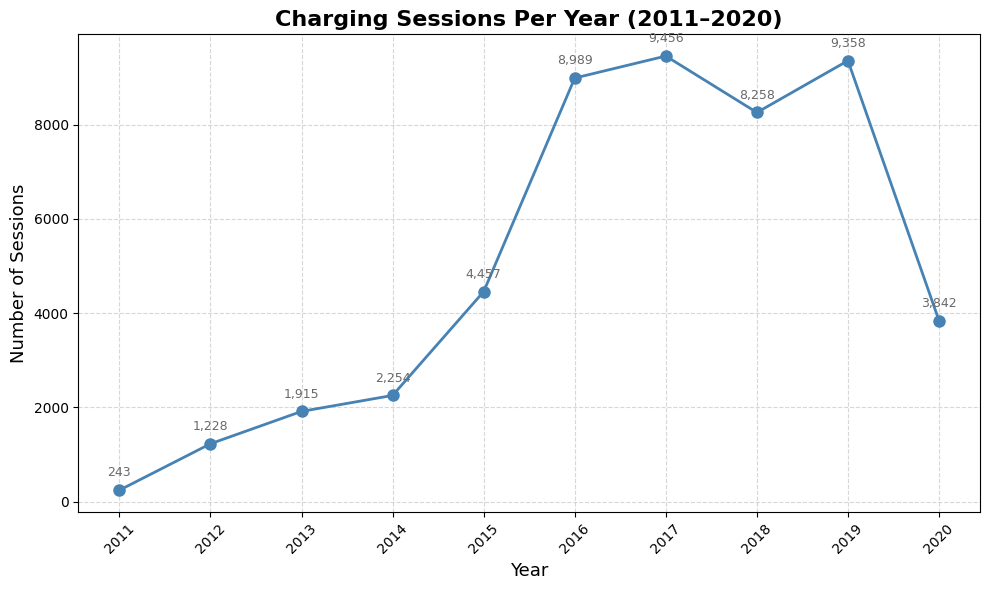

In [20]:
# Chart 1: sessions per year
yearly = sql_df("""
    SELECT EXTRACT(YEAR, start_ts) AS year, COUNT(*) AS sessions
    FROM ev_charging_sessions
    GROUP BY year
    ORDER BY year
""")
generate_and_run_chart(
    yearly,
    "a line chart of charging sessions per year from 2011 to 2020, with a marker on each point",
    save_path="images/img6-sessions-per-year.png",
)

#### Chart 2: The Busiest Hours of the Day

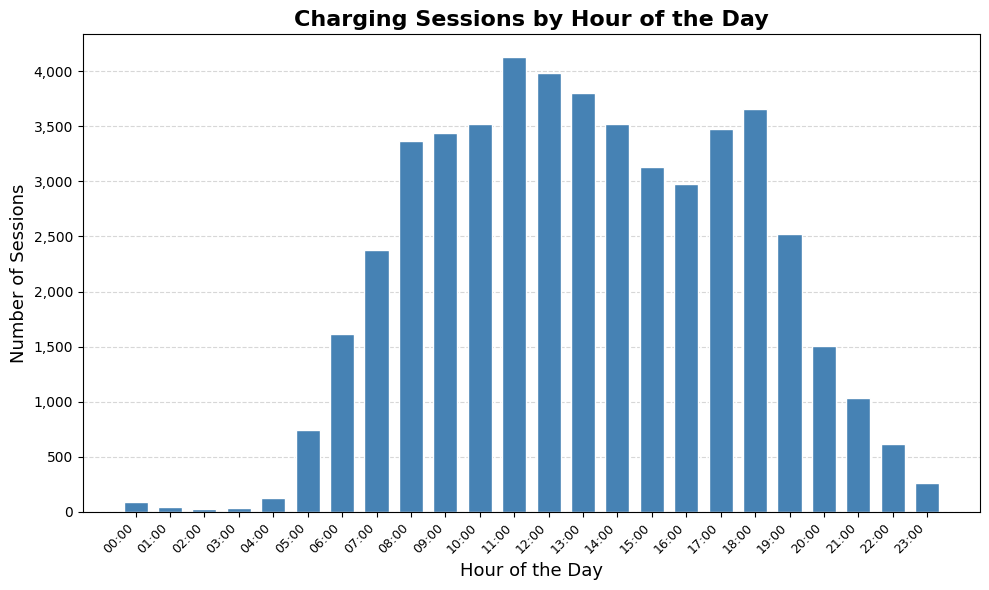

In [21]:
# Chart 2: sessions by hour of day
hourly = sql_df("""
    SELECT EXTRACT(HOUR, start_ts) AS hour, COUNT(*) AS sessions
    FROM ev_charging_sessions
    GROUP BY hour
    ORDER BY hour
""")
generate_and_run_chart(
    hourly,
    "a bar chart of charging sessions by hour of the day, from hour 0 to 23",
    save_path="images/img7-sessions-by-hour.png",
)

#### Chart 3: The Busiest Stations

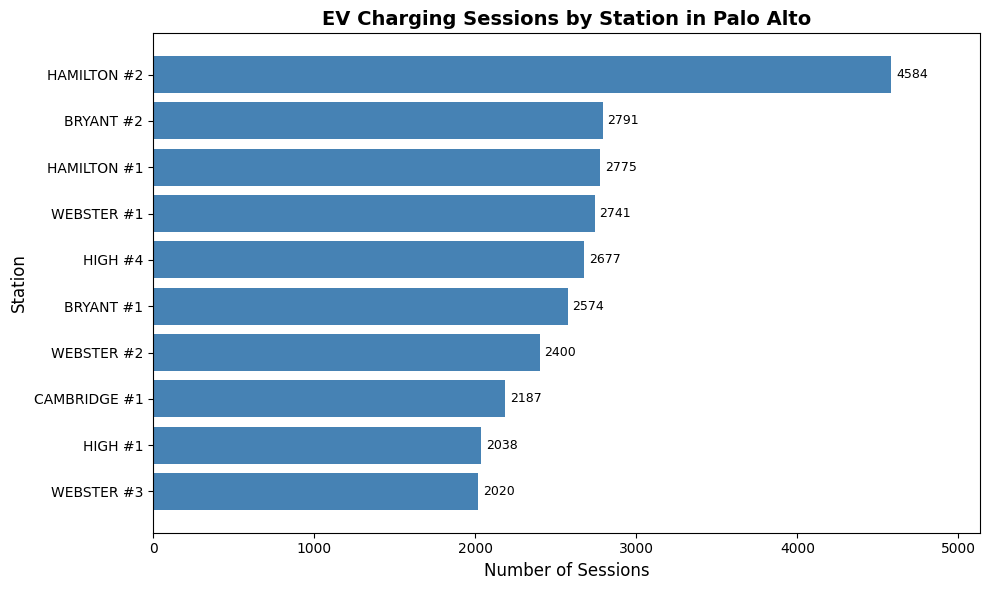

In [22]:
# Chart 3: top stations by sessions
stations = sql_df("""
    SELECT station_name, COUNT(*) AS sessions
    FROM ev_charging_sessions
    GROUP BY station_name
    ORDER BY sessions DESC
    LIMIT 10
""")
generate_and_run_chart(
    stations,
    "a horizontal bar chart of sessions per station with the busiest at the top, "
    "using short labels that drop the 'PALO ALTO CA /' prefix",
    save_path="images/img8-top-stations.png",
)

#### Chart 4: How Long Sessions Last

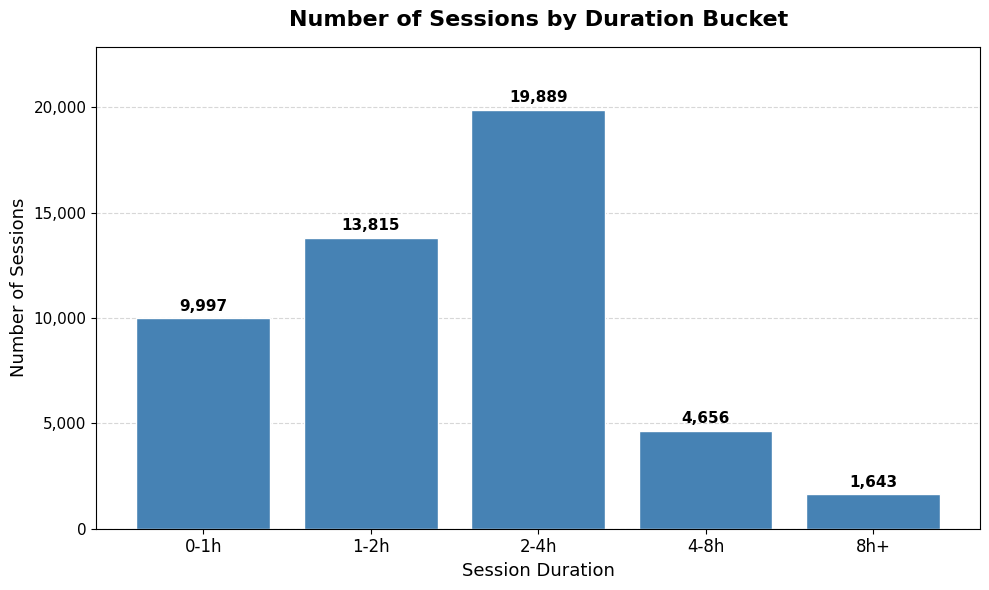

In [23]:
# Chart 4: session duration buckets
duration_buckets = sql_df("""
    SELECT
      CASE
        WHEN TIMESTAMP_DIFF(MINUTE, end_ts, start_ts) < 60  THEN '0-1h'
        WHEN TIMESTAMP_DIFF(MINUTE, end_ts, start_ts) < 120 THEN '1-2h'
        WHEN TIMESTAMP_DIFF(MINUTE, end_ts, start_ts) < 240 THEN '2-4h'
        WHEN TIMESTAMP_DIFF(MINUTE, end_ts, start_ts) < 480 THEN '4-8h'
        ELSE '8h+'
      END AS duration_bucket,
      COUNT(*) AS sessions
    FROM ev_charging_sessions
    GROUP BY duration_bucket
""")
generate_and_run_chart(
    duration_buckets,
    "a bar chart of the number of sessions in each duration bucket, "
    "ordered 0-1h, 1-2h, 2-4h, 4-8h, 8h+",
    save_path="images/img9-session-duration.png",
)

#### Chart 5: Energy Delivered per Year

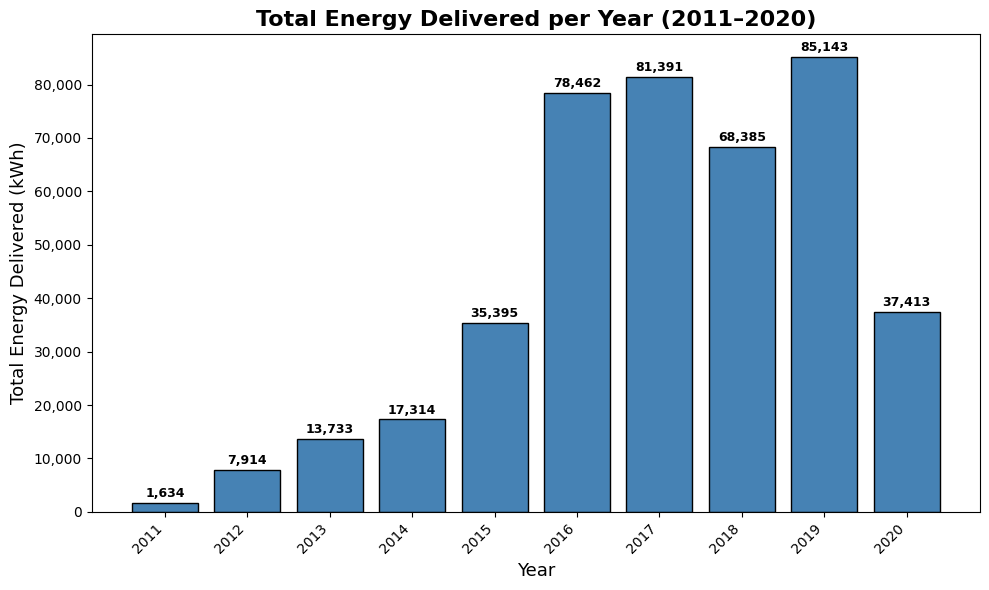

In [24]:
# Chart 5: total energy delivered per year
energy = sql_df("""
    SELECT EXTRACT(YEAR, start_ts) AS year, ROUND(SUM(energy_kwh), 0) AS total_kwh
    FROM ev_charging_sessions
    GROUP BY year
    ORDER BY year
""")
generate_and_run_chart(
    energy,
    "a bar chart of total energy delivered in kilowatt hours per year from 2011 to 2020",
    save_path="images/img10-energy-per-year.png",
)

#### Chart 6: Monthly Sessions in 2019 and 2020

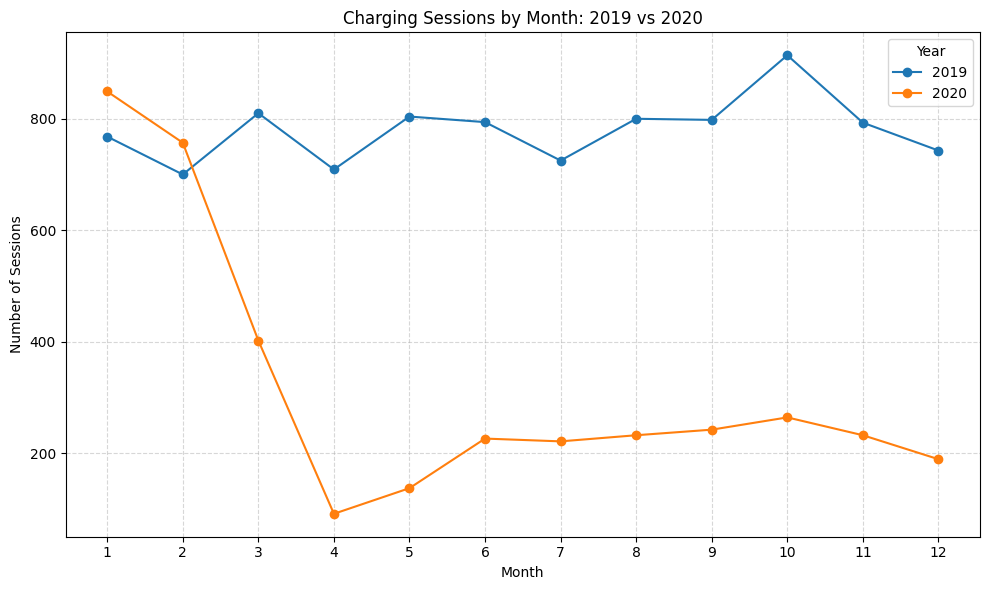

In [25]:
# Chart 6: monthly sessions in 2019 vs 2020
monthly_2yr = sql_df("""
    SELECT EXTRACT(YEAR, start_ts) AS year,
           EXTRACT(MONTH, start_ts) AS month,
           COUNT(*) AS sessions
    FROM ev_charging_sessions
    WHERE start_ts >= TIMESTAMP('2019-01-01T00:00:00Z')
    GROUP BY year, month
    ORDER BY year, month
""")
generate_and_run_chart(
    monthly_2yr,
    "a line chart comparing charging sessions by month for 2019 and 2020, with one "
    "line per year, the month number 1 to 12 on the x axis, a legend, and a marker on each point",
    save_path="images/img11-monthly-2019-2020.png",
)

## Conclusion